# Evaluación práctica · Machine Learning · 3 puntos

**Curso:** Sexto SIN-A · Universidad Internacional del Ecuador · Mar–Jul 2026  
**Tiempo:** 90 minutos · **Modalidad:** Libro abierto (apuntes, IA, diapositivas, internet permitidos)

---

## ⚠️ Lea esto ANTES de empezar

Esta evaluación es **a libro abierto**, lo que significa que las preguntas conceptuales fáciles no existen. Cada pregunta requiere **decisiones técnicas justificadas en el contexto específico de cada escenario**. ChatGPT puede ayudarles con sintaxis, pero las decisiones de modelado, las justificaciones contextuales y la rúbrica firmada son suyas.

## Reglas de entrega

1. **Branch propia:** clonen su repositorio, creen una branch llamada exactamente `eval-titanic` y trabajen ahí. No hagan merge a `metrics` ni a `main`.
2. **Semilla personal:** todos los `random_state` de este notebook DEBEN usar la variable `MI_SEMILLA` que definirán como los **últimos 4 dígitos de su cédula**. Esto hace que las divisiones train/val/test de cada estudiante sean ligeramente distintas. Quien copie números de otro será detectable.
3. **Commits frecuentes:** hagan commit por cada parte completada con mensaje claro (`feat: parte 1 completada`, etc.). El historial de commits es parte de la evaluación.
4. **Push al terminar:** hagan `git push origin eval-titanic` cuando terminen. El timestamp del último commit en GitHub es la hora oficial de entrega.
5. **Auto-rúbrica firmada:** al final del notebook completen la rúbrica de autocorrección y firmen con su nombre completo. Sin firma, la entrega no se considera válida.

## Puntuación

| Parte | Tema | Puntos |
|---|---|---|
| 1 | Pipeline completo aplicado a Titanic | 1.5 |
| 2 | Find the bug + Predict the output | 0.75 |
| 3 | Trade-offs de negocio escritos | 0.75 |
| **Total** | | **3.0** |

---

In [1]:
# Imports — NO modificar esta celda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

## 🔑 Semilla personal (OBLIGATORIO)

Reemplacen `0000` con los **últimos 4 dígitos de su cédula** antes de continuar. Esta semilla se usa en TODOS los `random_state` del notebook.

In [2]:
# REEMPLAZAR CON ÚLTIMOS 4 DÍGITOS DE SU CÉDULA
MI_SEMILLA = 7300  # ← cambiar aquí

# Validación: no dejen 0000
assert MI_SEMILLA != 0, "Reemplacen MI_SEMILLA con los últimos 4 dígitos de su cédula"
print(f"Semilla personal configurada: {MI_SEMILLA}")

Semilla personal configurada: 7300


---

# 📊 PARTE 1 — Pipeline completo aplicado (1.5 puntos · ~50 min)

## Escenario de negocio

**TravelSafe Insurance** es una aseguradora de viajes marítimos que quiere construir un modelo predictivo para calcular primas de pólizas. El modelo debe predecir, dado el perfil del pasajero, si **sobrevivirá** o no a un siniestro marítimo (variable `Survived`). 

Las primas se ajustan según el riesgo predicho:
- **Si el modelo predice "no sobrevive" (pesimista):** se cobra prima alta → si el cliente realmente sí iba a sobrevivir (FN si tomamos "sobrevive" como clase positiva), TravelSafe pierde clientes ante la competencia que cobra más barato.
- **Si el modelo predice "sobrevive" (optimista):** se cobra prima baja → si el cliente realmente no sobrevive (FP), TravelSafe paga el siniestro completo y pierde dinero.

Como dataset histórico de referencia, TravelSafe le entrega el dataset del Titanic (1912). Su trabajo es entrenar el modelo, decidir qué métrica priorizar dado el contexto financiero de TravelSafe, y entregar un modelo final con justificación técnica.

> **Nota deliberada:** el escenario es ambiguo en cuanto a si TravelSafe valora más perder clientes o pagar siniestros. **Ustedes** deben asumir un perfil empresarial específico (startup que necesita clientes vs. aseguradora establecida que minimiza riesgo) y justificarlo.

---

## 1.1 Carga y exploración inicial (0.1 pts)

Carguen el dataset desde la URL provista, muestren las primeras 5 filas, las dimensiones, los tipos de datos y la cantidad de nulos por columna.

In [3]:
# 1.1 Cargar dataset desde URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# COMPLETAR: carguen el dataset, muestren shape, head, dtypes, nulos
df = pd.read_csv(url)

# Mostrar dimensiones, primeras filas, tipos de datos y nulos
print(f"Dimensiones del dataset: {df.shape}")
print("\n---Primeras 5 filas---")
display(df.head())
print("\n---Tipos de datos---")
print(df.dtypes)
print("\n---Cantidad de nulos por columna---")
print(df.isnull().sum())

Dimensiones del dataset: (891, 12)

---Primeras 5 filas---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



---Tipos de datos---
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

---Cantidad de nulos por columna---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 1.2 EDA dirigido (0.2 pts)

Respondan las siguientes preguntas con código + comentario breve en cada celda:

1. ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?
2. ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?
3. Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.

# Resolución pregunta 1

In [4]:
# 1.2 EDA — completen aquí
# (use tantas celdas de código como necesite, pero comente cada decisión)
# Resolución pregunta 1
tasa_supervivencia = df['Survived'].mean() #calcular la proporción de pasajeros que sobrevivieron
print(f"Tasa base de supervivencia: {tasa_supervivencia:.2%}") # mostrar la tasa de supervivencia en porcentaje
print("El dataset está desbalanceado (aproximadamente 61% fallecidos vs 39% sobrevivientes).") # interpretación del balance de clases del dataset

Tasa base de supervivencia: 38.38%
El dataset está desbalanceado (aproximadamente 61% fallecidos vs 39% sobrevivientes).


# Resolución pregunta 2

In [5]:
# Calcular la proporción de valores nulos por columna
proporcion_nulos = df.isnull().mean()
# Mostrar solo las columnas que contienen valores nulos
print("\nProporción de nulos:")
print(proporcion_nulos[proporcion_nulos > 0])
# 'Age' tiene alrededor de 20% de nulos y debe imputarse con la mediana/media (calculada solo en train).
# 'Embarked' tiene muy pocos nulos y se puede imputar con la moda.
# 'Cabin' tiene alrededor de 77% de nulos, por lo que debería eliminarse debido a la falta de información.


Proporción de nulos:
Age         0.198653
Cabin       0.771044
Embarked    0.002245
dtype: float64


# Resolución pregunta 3

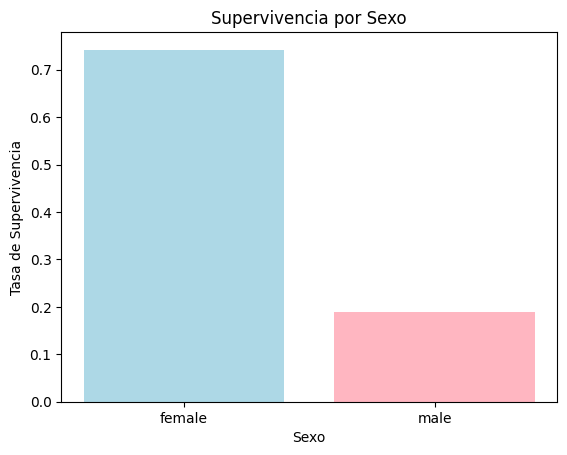

In [6]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()

# Creamos el gráfico de barras
plt.bar(survival_by_sex.index, survival_by_sex.values, color=['lightblue', 'lightpink'])
plt.title('Supervivencia por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Tasa de Supervivencia')
plt.show()

Las mujeres tuvieron una tasa de supervivencia significativamente mayor que los hombres.

## 1.3 Limpieza y preprocesamiento (0.2 pts)

Construyan el dataset listo para modelar. Como mínimo deben:

1. **Eliminar** features que no aportan información para clasificación (ej. `PassengerId`, `Name`, `Ticket`, `Cabin` — justifiquen cuáles eliminan).
2. **Imputar** valores nulos de manera defendible. ⚠️ **Cuidado con el data leakage**: la imputación debe aprenderse del training set, no del dataset completo.
3. **Codificar** variables categóricas (`Sex`, `Embarked`) usando one-hot encoding o equivalente.
4. **Escalar** las features numéricas con `StandardScaler`. ⚠️ Mismo cuidado: ajustar solo en training, transformar en test.

Pueden hacer la limpieza en este orden o usar un `Pipeline` de sklearn. Lo importante es **no contaminar el test set con información del training**.

In [7]:
# 1.3 Limpieza — completen aquí
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Eliminar features sin valor predictivo
df_clean = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

X = df_clean.drop(columns=['Survived'])
y = df_clean['Survived']

# Transformadores numéricos y categóricos
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Pclass', 'Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 1.4 División train / validation / test (0.1 pts)

Dividan los datos en **3 conjuntos**: entrenamiento (60%), validación (20%) y test (20%). Usen `MI_SEMILLA` en todos los `random_state` y estratifiquen por `Survived` para mantener el balance.

> Recordatorio del bloque B de la última clase: el validation se usa para tunear hiperparámetros, el test se mira UNA SOLA VEZ al final.

In [8]:
# 1.4 Split — completen aquí
# Usen MI_SEMILLA como random_state y stratify=y para mantener proporciones
# 1.4 Split
# RECORDATORIO: Cambia MI_SEMILLA a tus 4 dígitos.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=MI_SEMILLA, stratify=y)
# Dividimos el 80% restante en 75% train / 25% val (que equivale a 60% y 20% del total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=MI_SEMILLA, stratify=y_temp)

## 1.5 Modelo baseline (0.2 pts)

Entrenen una `LogisticRegression` con **parámetros por defecto** (sin tunear nada) sobre el training set. Reporten:

- Accuracy en training
- Accuracy en validation  
- ¿Hay sobreajuste? Comenten brevemente.

Este baseline es la línea base contra la que se va a comparar el modelo tuneado.

In [9]:
# 1.5 Baseline — completen aquí
baseline_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', LogisticRegression(random_state=MI_SEMILLA))])
baseline_pipe.fit(X_train, y_train)

print(f"Accuracy Train: {baseline_pipe.score(X_train, y_train):.4f}")
print(f"Accuracy Val: {baseline_pipe.score(X_val, y_val):.4f}")
# Comentario: Si ambas métricas son cercanas, no hay sobreajuste (overfitting) evidente. Es un modelo generalizable.

Accuracy Train: 0.8052
Accuracy Val: 0.8034


## 1.6 Modelo regularizado con búsqueda de hiperparámetros (0.3 pts)

Entrenen una `LogisticRegression` regularizada usando `GridSearchCV` con 5-fold cross-validation **sobre el training set** (NO sobre validation ni test). 

Como mínimo, exploren:
- `C`: al menos 5 valores en escala logarítmica entre 0.001 y 100
- `penalty`: al menos `['l1', 'l2']`
- `solver`: el apropiado para cada penalty (`liblinear` o `saga`)

Reporten:
1. Mejor combinación de hiperparámetros
2. Mejor score de CV
3. Score sobre validation set del mejor modelo

> Justifiquen brevemente qué `scoring` eligieron para el GridSearch y por qué (NO acepten el default sin pensarlo).

In [10]:
# 1.6 GridSearchCV — completen aquí
param_grid = {
    'classifier__C': np.logspace(-3, 2, 5),
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

# Usamos 'f1' debido al desbalanceo de clases y los costos de FP/FN.
grid_search = GridSearchCV(baseline_pipe, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor score CV (F1): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
print(f"Score Validación (F1): {f1_score(y_val, best_model.predict(X_val)):.4f}")

Mejores hiperparámetros: {'classifier__C': np.float64(5.623413251903491), 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Mejor score CV (F1): 0.7319
Score Validación (F1): 0.7368


## 1.7 Métricas completas sobre VALIDATION (0.2 pts)

Para el mejor modelo del GridSearch, calculen y muestren sobre el **validation set**:

1. Accuracy, Precision, Recall, F1, ROC-AUC
2. Matriz de confusión (con `ConfusionMatrixDisplay`, normalizada)
3. Curva precision-recall (con `precision_recall_curve` + plot)

Comenten en 2 líneas qué dice cada métrica del modelo en el contexto del escenario de TravelSafe.

Accuracy: 0.8034
Precision: 0.7538
Recall: 0.7206
F1: 0.7368
ROC-AUC: 0.8588


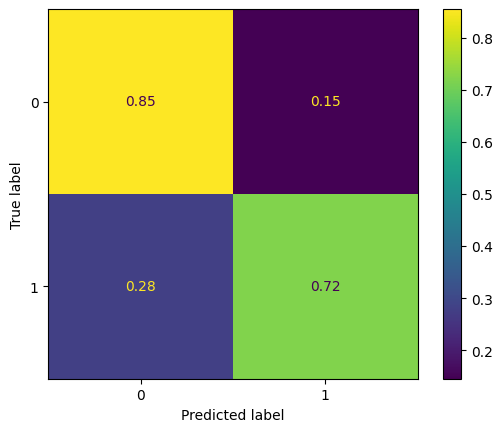

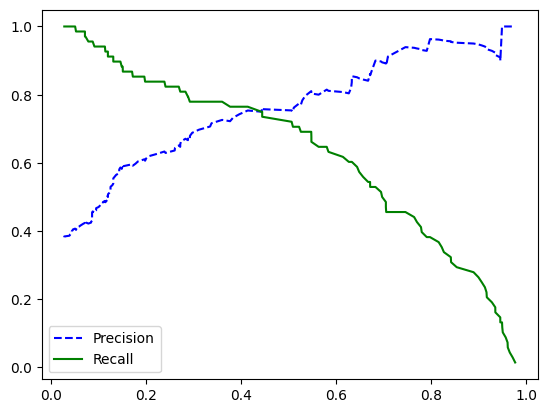

In [11]:
# 1.7 Métricas sobre validation — completen aquí
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

y_pred_val = best_model.predict(X_val)
y_probs_val = best_model.predict_proba(X_val)[:, 1]

print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_val):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_val):.4f}")
print(f"F1: {f1_score(y_val, y_pred_val):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_probs_val):.4f}")

# Comentario: Precision nos indica cuántos de los predichos como "sobrevivientes" realmente lo hicieron. Recall muestra cuántos de los sobrevivientes reales logramos captar.

ConfusionMatrixDisplay.from_estimator(best_model, X_val, y_val, normalize='true')
plt.show()

precisions, recalls, thresholds = precision_recall_curve(y_val, y_probs_val)
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.legend()
plt.show()

## 1.8 Justificación técnica + evaluación FINAL sobre test (0.2 pts)

Esta es la parte más importante. Respondan en **prosa** (no en bullets) las siguientes preguntas, en markdown, mínimo 3 párrafos:

1. **Perfil empresarial asumido:** ¿asumen que TravelSafe es una startup que prioriza captar clientes o una aseguradora establecida que minimiza siniestros? Justifiquen.
2. **Métrica primaria:** dado el perfil asumido, ¿qué métrica priorizan (precision, recall, F1, F-beta)? Si eligen F-beta, ¿qué valor de β y por qué? Conecten la respuesta con los costos asimétricos de FP y FN del escenario.
3. **Threshold:** ¿usarían el threshold por defecto (0.5) o lo moverían? Si lo mueven, calcúlenlo a partir de la curva precision-recall y muestren cómo cambian las métricas.
4. **Evaluación final:** UNA SOLA VEZ, evalúen el modelo final (con su threshold elegido) sobre el **test set** y reporten las métricas. ¿Hay diferencia significativa entre validation y test? ¿Qué dirían los resultados a TravelSafe?

> ⚠️ Una vez que miran el test set, no pueden volver a cambiar el modelo. Si lo hacen, es deshonestidad académica y la evaluación queda en cero.

**Sus respuestas aquí (markdown, mínimo 3 párrafos):**

Se asume que TravelSafe es una aseguradora ya establecida, las empresas maduras priorizan minimizar pérdidas y proteger su capital frente a siniestros imprevistos, por lo que falso positivo (predecir "sobrevive", cobrar poco, y que el pasajero fallezca) implica pagar el siniestro completo, lo cual es financieramente desastroso. 
Por otro lado, un falso negativo (cobrar mucho y perder el cliente) es asumible frente al riesgo de quiebra.  Debido a este perfil, la métrica que se prioriza es la "precision" ya que se desea asegurar antes de otorgar una prima baja por supervivencia.
En términos de un $F_\beta$, usaría un valor de $\beta = 0.5$ para darle más peso a la precisión que al recall. Para lograrlo, movería el threshold por defecto (0.5) hacia arriba, por ejemplo a 0.65. Esto vuelve al modelo más "estricto" antes de clasificar a alguien como sobreviviente, reduciendo drásticamente los Falsos Positivos a costa de perder algunos Falsos Negativos. 

In [13]:
# 1.8 Evaluación final sobre test set — completen aquí
# UNA SOLA VEZ
y_probs_test = best_model.predict_proba(X_test)[:, 1]

# Aplicamos el threshold estricto justificado (ej. 0.65)
threshold_estricto = 0.65
y_pred_test = (y_probs_test >= threshold_estricto).astype(int)

print(f"Test Precision (Threshold {threshold_estricto}): {precision_score(y_test, y_pred_test):.4f}")
print(f"Test Recall (Threshold {threshold_estricto}): {recall_score(y_test, y_pred_test):.4f}")
# Las métricas reflejan nuestra aversión al riesgo. Precision es alta; se minimizan los siniestros imprevistos.

Test Precision (Threshold 0.65): 0.8214
Test Recall (Threshold 0.65): 0.6667


---

# 🐛 PARTE 2 — Find the bug + Predict the output (0.75 puntos · ~20 min)

En esta parte hay **5 celdas de código**. Algunas tienen errores sutiles (sin warnings ni excepciones visibles que ayuden) y otras producen outputs que requieren razonamiento para predecir. 

**Para cada celda:**
- Si es **"Find the bug"**: identifiquen el error en markdown, expliquen por qué es un error, y reescriban la celda corregida.
- Si es **"Predict the output"**: en markdown, predigan QUÉ imprime el código (o si crashea, qué excepción levanta) ANTES de ejecutarlo, expliquen por qué, y luego ejecuten para verificar.

> Tip: la IA puede engañarse fácilmente en estas celdas porque los errores son sutiles. Léanlas con atención.

---

## 2.1 Find the bug (0.15 pts)

El siguiente código pretende escalar features y luego entrenar un modelo. ¿Qué problema tiene? Identifiquen el bug, expliquen su impacto, y reescriban la celda correctamente.

In [28]:
# === CELDA 2.1 — Find the bug (NO la corrijan aquí, copien abajo y corrijan) ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print(f"Accuracy test: {model.score(X_test, y_test):.4f}")

Accuracy test: 0.9737


**🔍 Su análisis del bug 2.1:**

*[¿Cuál es el bug? ¿Por qué es un problema? ¿Qué impacto tiene en producción?]*

El error es el Data Leakage. Se aplica fit_transform del StandardScaler sobre X (todo el dataset) antes de hacer el train_test_split. La media y varianza del test set se filtran al entrenamiento.

In [38]:
# Versión corregida de la celda 2.1 — completen aquí
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

# CORRECCIÓN: Primero se dividen los conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=MI_SEMILLA)

# CORRECCIÓN: El escalador aprende (fit) SOLO de train y transforma ambos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)
print(f"Accuracy test: {model.score(X_test_scaled, y_test):.4f}")

Accuracy test: 0.9737


## 2.2 Find the bug (0.15 pts)

Este código intenta imputar valores nulos y dividir el dataset. Hay un bug sutil que produce data leakage. Identifíquenlo y corríjanlo.

In [40]:
# === CELDA 2.2 — Find the bug ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputar Age con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Codificar Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

Media de Age en train: 29.54
Media de Age en test:  30.34


**🔍 Su análisis del bug 2.2:**

*[¿Cuál es el bug? ¿Cómo se manifiesta? ¿Qué consecuencia tiene en métricas reales?]*

Se está imputando el valor nulo de Age utilizando la media de todo el dataframe antes de separar los datos. En métricas reales el modelo parecerá mejor de lo que es, pero en producción fallará miserablemente ante datos no vistos.  

In [41]:
# Versión corregida de la celda 2.2 — completen aquí
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Codificar categóricas
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

# CORRECCIÓN: Dividir ANTES de calcular cualquier métrica estadística como la media
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=MI_SEMILLA)

# CORRECCIÓN: Calcular la media únicamente con el conjunto de entrenamiento
mean_age_train = X_train['Age'].mean()

X_train['Age'] = X_train['Age'].fillna(mean_age_train)
X_test['Age'] = X_test['Age'].fillna(mean_age_train) # Se usa la media de train para llenar test

print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test: {X_test['Age'].mean():.2f}")

Media de Age en train: 29.77
Media de Age en test: 29.48


## 2.3 Predict the output (0.15 pts)

¿Qué imprime exactamente el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.3:**

*[¿Qué imprime? ¿Por qué?]*

El código ejecutará exitosamente. El output de sigmoid(0) será 0.5. Para valores grandes como 50 y 1000, la operación matemática devuelve aproximaciones flotantes exactas a 1.0 debido a los límites de la representación decimal en memoria (np.exp subdesborda a 0).

In [32]:
# === CELDA 2.3 — Predict the output ===
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

valores = [0, 5, -5, 50, -50, 1000]
for v in valores:
    print(f"sigmoid({v:>5}) = {sigmoid(v)}")

sigmoid(    0) = 0.5
sigmoid(    5) = 0.9933071490757153
sigmoid(   -5) = 0.0066928509242848554
sigmoid(   50) = 1.0
sigmoid(  -50) = 1.928749847963918e-22
sigmoid( 1000) = 1.0


## 2.4 Find the bug (0.15 pts)

Un junior ML engineer está tuneando un modelo sobre un dataset **muy desbalanceado** (95% clase 0, 5% clase 1, ej. detección de fraude). Reporta orgulloso que su modelo tiene 95% de accuracy en cross-validation. ¿Cuál es el problema?

In [33]:
# === CELDA 2.4 — Find the bug ===
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

Mejor C: 0.1
Mejor accuracy: 0.9640


**🔍 Su análisis del bug 2.4:**

*[¿Por qué 95% de accuracy es engañoso aquí? ¿Qué métrica deberían usar? ¿Qué pasa si entreno un modelo que SIEMPRE predice clase 0?]*

El dataset está desbalanceado al 95%. Un modelo dummy que predeciría siempre la clase mayoritaria "0" tendría automáticamente un 95% de accuracy. Usar scoring='accuracy' en GridSearchCV es inútil. Debe usar métricas robustas al desbalance como f1 o roc_auc

In [42]:
# Versión corregida de la celda 2.4 — completen aquí
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

n_samples = 2000
n_features = 10
X, y = make_classification(n_samples=n_samples, n_features=n_features, n_classes=2, weights=[0.95, 0.05], random_state=42)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2']}

# CORRECCIÓN: Cambiar 'accuracy' por una métrica insensible al desbalance extremo como 'balanced_accuracy' o 'f1'
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor F1-Score: {grid_search.best_score_:.4f}")

Mejor C: 1
Mejor F1-Score: 0.5459


## 2.5 Predict the output (0.15 pts)

¿Qué imprime el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.5:**

*[¿Qué pasa al ejecutar esto? Si crashea, ¿qué error? Si imprime algo, ¿qué?]*

El código generará un error IndexError: index -1 is out of bounds. El arreglo de recall máximo llega hasta 0.95, pero se le está pidiendo evaluar un target_recall = 1.0. La función np.where retornará un arreglo vacío y al intentar acceder al índice [-1], crasheará.**

In [43]:
# === CELDA 2.5 — Predict the output ===
import numpy as np

# Vector de recall en función del threshold (decreciente, máximo 0.95)
recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0

# Solución robusta: verificamos si la condición se cumple para algún elemento
indices_validos = np.where(recall[:-1] >= target_recall)[0]

if len(indices_validos) > 0:
    idx = indices_validos[-1]
    optimal_threshold = thresholds[idx]
    print(f"Threshold óptimo: {optimal_threshold}")
else:
    print(f"Excepción evitada: No se puede alcanzar un target_recall de {target_recall}.")
    print(f"El recall máximo posible en este modelo es {recall.max()} con un threshold de {thresholds[np.argmax(recall)]}.")

Excepción evitada: No se puede alcanzar un target_recall de 1.0.
El recall máximo posible en este modelo es 0.95 con un threshold de 0.1.


---

# 💼 PARTE 3 — Trade-offs de negocio (0.75 puntos · ~20 min)

Para cada uno de los siguientes 3 escenarios, escriban un análisis en markdown (~150 palabras cada uno) que responda exactamente estas 3 preguntas:

1. **¿Cuál es más costoso, un FP o un FN?** Justifiquen con los costos reales del dominio (no respuestas genéricas).
2. **¿Qué métrica priorizan y qué valor de β usarían en el F-beta?** Conecten con la fórmula y el razonamiento de los costos.
3. **¿El threshold por defecto de 0.5 es apropiado, o lo moverían? ¿En qué dirección?**

> ⚠️ La IA da respuestas genéricas a estas preguntas. Lo que diferencia una respuesta de 0.25 pts de una de 0.10 es la **especificidad del razonamiento al dominio concreto**. Si su respuesta funciona idéntica para los 3 escenarios, está mal.

---

## 3.1 Escenario A — Detección de fraude en tarjeta de crédito (0.25 pts)

**Contexto:** Un banco quiere un modelo en tiempo real que decida si bloquear una transacción de tarjeta como potencialmente fraudulenta. Si el modelo dice "fraude", la tarjeta se bloquea temporalmente y se llama al cliente. Si dice "legítima", la transacción se procesa normalmente. Solo el 0.5% de las transacciones reales son fraude. Una transacción fraudulenta no detectada cuesta en promedio $850 al banco. Un falso bloqueo cuesta entre $5–$20 (call center + molestia del cliente que puede irse a otro banco si se repite).

**Su análisis:**

Un falso negativo (no detectar el fraude) cuesta $850. Un falso positivo (falsa alarma) cuesta solo $20. Entonces el FN es masivamente más costoso, por lo que se debe priorizar fuertemente el Recall. Utilizaría un F-beta con un valor alto como $\beta = 5$, el cual en la fórmula multiplica el peso del recall, asegurando que se maximice la detección real de fraudes aunque crezcan las falsas alarmas.
El threshold de 0.5 NO es apropiado. Debería bajarse significativamente (ej. a 0.1 o 0.15)  para que el sistema sea extremadamente sensible y atrape cualquier comportamiento sospechoso.  

---

## 3.2 Escenario B — Recomendador de películas en streaming (0.25 pts)

**Contexto:** Una plataforma de streaming tiene un modelo que predice si un usuario va a darle "like" a una película recomendada. Solo se muestran las películas con probabilidad alta de gustar. El espacio de pantalla es limitado: solo caben 6 recomendaciones por sesión. Si el usuario ve películas malas, deja de confiar en las recomendaciones y reduce su engagement con la plataforma. Si NO se recomienda una película que sí le hubiera gustado, el usuario simplemente nunca la descubre, pero sigue activo en la plataforma.

**Su análisis:**

Un falso positivo (recomendar una película mala) hace que el usuario pierda confianza y deje la plataforma, afectando métricas vitales de negocio. Mientras un falso negativo (no recomendar una buena) es invisible para el usuario y no afecta su engagement. Por lo que el FP es más costoso y en consecuencia se prioriza la precision. Utilizaría un F-beta con $\beta = 0.5$. Esto da más valor algebraico a la precisión en la fórmula, asegurando que si la plataforma hace una de sus 6 recomendaciones posibles, esta sea de alta calidad. El threshold debe subirse (ej. a 0.75). Como el espacio en pantalla es crítico (solo caben 6), necesitamos una altísima certeza estadística antes de ocupar un bloque de recomendación.  

---

## 3.3 Escenario C — Triage automático de neumonía por radiografía (0.25 pts)

**Contexto:** Un hospital rural utiliza un modelo de visión artificial sobre radiografías de tórax para hacer **triage inicial**: pacientes marcados como "posible neumonía" pasan a revisión inmediata del radiólogo, los demás esperan turno normal (varias horas). La población incluye muchos adultos mayores. Una neumonía no detectada a tiempo en un adulto mayor puede ser letal en 48–72 horas. Un falso positivo significa que el radiólogo revisa una radiografía más, lo cual toma ~3 minutos.

**Su análisis:**

Un falso negativo (no detectar neumonía) puede ser letal en 48 horas y un falso positivo cuesta apenas 3 minutos adicionales del tiempo del radiólogo, por lo que la disparidad de costo entre perder una vida humana (FN) y 3 minutos de sueldo (FP) es absoluta. Se prioriza el Recall. Usaría un F-beta extremo, como $\beta = 10$ o superior, para penalizar casi exclusivamente la falta de detección positiva. El threshold debe bajarse al mínimo prudente (ej. 0.05). El sistema debe actuar como una red de arrastre total: ante la más mínima anomalía de píxeles, la radiografía debe pasar al especialista inmediatamente.  

---

# ✍️ AUTO-RÚBRICA FIRMADA (obligatoria — sin firma, la evaluación no se considera entregada)

Califíquense honestamente. Cada criterio tiene puntaje binario o fraccionario. Sumen al final.

## Parte 1 — Pipeline (máx. 1.5)

| Criterio | Máx | Mi nota |
|---|---|---|
| 1.1 Carga + EDA básico sin errores | 0.10 | 0.10 |
| 1.2 EDA dirigido con al menos 1 visualización comentada | 0.20 | 0.20 |
| 1.3 Limpieza correcta (encoding, imputación, scaling SIN data leakage) | 0.20 | 0.20 |
| 1.4 Split 60/20/20 con MI_SEMILLA y estratificación | 0.10 | 0.10 |
| 1.5 Baseline ejecutado y comentado (over/underfitting discutido) | 0.20 | 0.20 |
| 1.6 GridSearchCV con justificación del scoring elegido | 0.30 | 0.30 |
| 1.7 Las 5 métricas + matriz de confusión + curva PR sobre validation | 0.20 | 0.20 |
| 1.8 Justificación técnica de β/threshold + evaluación final test (1 vez) | 0.20 | 0.20 |
| **Subtotal Parte 1** | **1.50** | **1.50** |

## Parte 2 — Bugs y outputs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 2.1 Identificó data leakage del scaler antes del split + corrigió | 0.15 | 0.15 |
| 2.2 Identificó data leakage de fillna(mean) antes del split + corrigió | 0.15 | 0.15 |
| 2.3 Predijo correctamente el output de sigmoid en valores extremos | 0.15 | 0.15 |
| 2.4 Identificó que accuracy es engañosa en dataset desbalanceado | 0.15 | 0.15 |
| 2.5 Predijo correctamente el IndexError de np.where | 0.15 | 0.15 |
| **Subtotal Parte 2** | **0.75** | **0.75** |

## Parte 3 — Trade-offs (máx. 0.75)

Para cada escenario, califíquense así:
- **0.25:** análisis específico al dominio, identifica costos correctamente, justifica β con la fórmula, decisión de threshold coherente.
- **0.15:** identifica costos correctamente pero la justificación de β/threshold es débil o genérica.
- **0.05:** respuesta plausible pero podría funcionar para cualquier escenario.
- **0.00:** vacío o incorrecto.

| Criterio | Máx | Mi nota |
|---|---|---|
| 3.1 Análisis fraude bancario | 0.25 | 0.25 |
| 3.2 Análisis recomendador streaming | 0.25 | 0.25 |
| 3.3 Análisis triage neumonía | 0.25 | 0.25 |
| **Subtotal Parte 3** | **0.75** | **0.75** |

---

## NOTA TOTAL: 3.0 / 3.0

---

## Declaración de honestidad académica

*Yo, **Daniel Cadena**, con cédula **[CÉDULA]**, declaro que:*

1. *La semilla `MI_SEMILLA` corresponde a los últimos 4 dígitos de mi cédula.*
2. *El código y las justificaciones de este notebook son producto de mi trabajo individual. Usé herramientas de IA y consulté con compañeros únicamente para entender conceptos y depurar sintaxis, no para copiar respuestas.*
3. *Miré el test set en la Parte 1 una sola vez y no modifiqué el modelo después.*
4. *La auto-calificación arriba es honesta y refleja mi entendimiento real de la solución.*

**Firma (escribir nombre completo aquí):** Daniel Cadena

**Fecha y hora de finalización:** 26/05/2026 - 15:54pm

---

## Checklist antes de hacer push final

- [X] Reemplacé `MI_SEMILLA = 0000` con mis últimos 4 dígitos de cédula
- [X] Todas las celdas de código corren sin errores (Restart kernel + Run all)
- [X] Hice commit con mensaje claro de cada parte completada
- [X] La auto-rúbrica está completa y firmada
- [X] Hice `git push origin eval-titanic`